<a href="https://colab.research.google.com/github/Eunsuk2/wed_2026_bigdatacomputing/blob/main/class_wed_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ 데이터 과학 파이프라인의 전 과정
- Numpy : 다차원 배열 생성, 결합(concatenate(), vstack(),hstack(), column_stack()), 셔플링, 필터링(인덱싱/슬라이싱)

- Pandas : 데이터 구조화, 타입 변환, 그룹 분석(groupby(), pivot_table(), concat(), merge()), 데이터 추출(인덱싱, 슬라이싱), 결측치 보간(fillna(), isna(), dropna())

- 시각화 : matplotlib, seaborn, Pandas의 시각화 기능, DataFrame의 시각화 기능

- 데이터 분석 흐름: 데이터 생성(Numpy) → 데이터 구조화(Pandas) → 정제(Pre-processing) → 탐색적 데이터 분석(EDA) : 시각화 순서로 진행

- NumPy 기반의 시뮬레이션 코드를 Pandas의 DataFrame 구조로 확장하면, 데이터에 이름을 붙이고(Indexing), 통계치를 한눈에 확인하며, 시각화 라이브러리와의 연동




## ✅ Pandas 기능
  - Series

In [1]:
#----------------------------
# Series : list, 난수배열, 딕셔너리
#----------------------------
import pandas as pd
import numpy as np

# 1. 자동 인덱스 생성하는 시리즈 객체 생성
s1 = pd.Series([1,2,3,4,np.nan,5])
# print(s1)
s2 = pd.Series(np.random.randn(6))
# print("\n", s2)
s3 = pd.Series({"일":1, "이":2, "삼":3})
# print("\n", s3)

# 2. 인덱스 변경
#(1) 인자 이용
s4 = pd.Series([1,2,3,4,5], index=['a','b','c','d','e'])
# print("\n", s4)

#(2) 속성 이용
data = [1,2,3,4,5]
s5 = pd.Series(data)
s5.index = ['a','b','c','d','e']
# print("\n", s5)

# 3. 결측치 처리
#(1) 결측치 확인 : 시리즈.isna() --> 불리언 시리즈 반환
s1 = pd.Series([1,2,3,4,np.nan,5])
# print(s1.isna())
#(2) 결측치 처리 : 시리즈.fillna()
# print("\n",s1.fillna(0, inplace = True))
# print("\n",s1)

# 4. 데이터 추출
#(1) 인덱싱
s1 = pd.Series([1,2,3,4,5])
# print("\n", s1)
# print("\n",s1[2])
# print("\n", s1[-1]) # 주의!
#(2) 슬라이싱
# print("\n", s1[1:3])
# print("\n", s1[:3])
#(3) 논리인덱싱
#print(s1[s1 < 3])

# 5. 시리즈 데이터 변경- 인덱스 이용
s1 = pd.Series([1,2,3,4,5])
s1[0] = 10
# print("\n",s1)

# 6. 시리즈에 데이터 추가 - 인덱스 이용
s1 = pd.Series([1,2,3,4,5])
s1[5] = 10
s1['오'] = 20
# print(s1)

# 7. 딕셔너리의 시리즈 데이터 추출
income = {'jan': 90000, 'feb': 890000, 'mar': 70000}
sd = pd.Series(income, name = 'income') # 시리즈에 이름 부여
print("\n",sd)
print(sd['jan'])
print(sd[['jan','mar']])
maxidx = np.argmax(sd)
print(maxidx) # 'feb', 1
print(sd[maxidx]) # 890000


 jan     90000
feb    890000
mar     70000
Name: income, dtype: int64
90000
jan    90000
mar    70000
Name: income, dtype: int64
1
890000


/tmp/ipykernel_4639/4227889288.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(sd[maxidx]) # 890000


## ✅ Pandas 기능
  - DataFrame 속성


       월    수입    지출
r1  jan  9700  9000
r2  feb  8900  8700
r3  mar  6000  6500
r4  apr  8000  7900
r5  may  9000  8900

        수입    지출
월              
jan  9700  9000
feb  8900  8700
mar  6000  6500
apr  8000  7900
may  9000  8900

        수입    지출   잔액 적자
월                      
jan  9700  9000  700  +
feb  8900  8700  200  +
mar  6000  6500 -500  -
apr  8000  7900  100  +
may  9000  8900  100  +


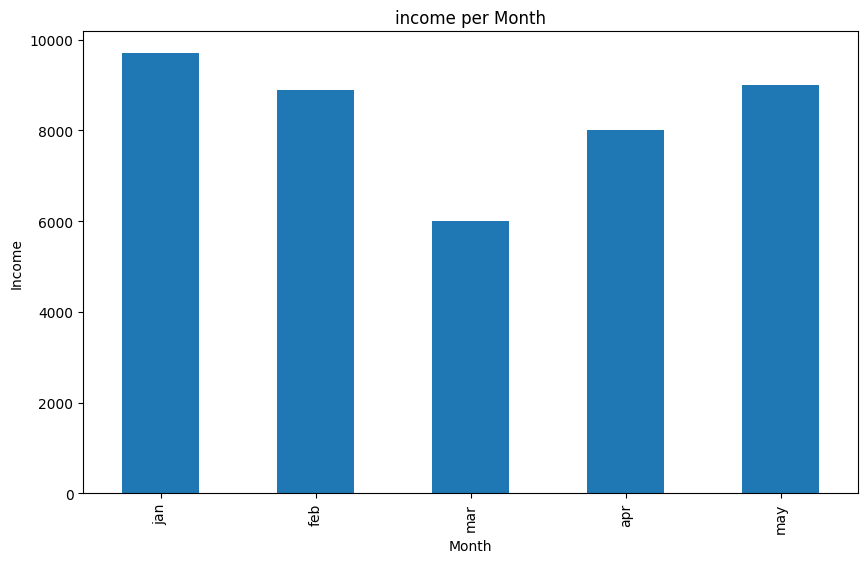


       수입    지출   잔액
적자                 
+   9700  9000  700
-   6000  6500 -500


In [2]:
#---------------------------------------------------------
# DataFrame : Series의 결합해서 만들때는 딕셔너리 이용함
#--------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------------
# 1. 데이터프레임 객체 생성
#---------------------------------------
# (1) 시리즈을 이용한 값 정의
month_s = pd.Series(['jan','feb','mar','apr','may']) # 5개월 월별 정보
income_s = pd.Series([9700, 8900, 6000, 8000, 9000]) # 5개월 수입 정보
expense_s = pd.Series([9000, 8700, 6500,7900, 8900]) # 5개월 지출 정보

# (2) 2차원 구조의 테이블 생성 : 딕셔너리 이용
df = pd.DataFrame({'월':month_s, '수입':income_s, '지출':expense_s})
#print(df)

#---------------------------------
# 2. 데이터프레임의 속성
#----------------------------------
#print("\n",df.index.to_list()) #[0,1,2,3,4] 인덱스 정보 추출
#print("\n", df.columns.to_list()) #['월', '수입', '지출'] 컬럼 정보 추출
#print("\n",df.values) # 넘파이의 2차원 배열

#-----------------------------------
# 3. 데이터프레임의 인덱스 재설정
#----------------------------------------
df. index = ["r1", "r2", "r3", "r4", "r5"]
print("\n", df)

# (1) 컬럼을 인덱스로 변경 : df.set_index()
df = df.set_index("월")
print("\n", df)

#-----------------------------------------
# 4. 데이터프레임의 특정 컬럼(열) 추출
#-----------------------------------------
#print("\n", df["수입"])
#print("\n", df[["수입","지출"]])


#-------------------------------------------
# 5. 데이터프레임의 특정 행 추출: df.loc[]
#-------------------------------------------
#print("\n", df.loc["jan"])
#print("\n", df.loc[["jan","mar"]])

#----------------------------------------------------
# 6. 데이터프레임의 특정 (행, 열)위치에 있는 값 추출 : df.loc[]
#----------------------------------------------------
#print("\n", df.loc["jan", "수입"])
#print("\n", df.loc[["jan","mar"], ["수입", "지출"]])

#---------------------------------------
# 7. 데이터프레임에 새로운 컬럼 추가
#---------------------------------------
df['잔액'] =df['수입'] -df['지출']
#print("\n", df)

#-----------------------------------------------
# 8. 논리 인덱싱 조건을 이용해서 새로운 컬럼 추가 : np.where()
#-----------------------------------------------
df['적자'] = np.where(df['잔액'] < 0, "-", "+") # 논리인덱싱
print("\n", df)

#------------------------------------------------------
# 행/열 삭제 : df.drop()
#------------------------------------------------------
df_drop_col = df.drop(columns=["잔액", "적자"], axis = 1, inplace = False)
#print("\n", df_drop_col)

df_drop_row = df.drop(index=["jan", "feb"], axis = 0, inplace = False)
#print("\n", df_drop_row)

#------------------------------------------------------
# 데이터프레임의 시각화
#------------------------------------------------------

plt.figure(figsize=(10, 6))
#plt.plot(df['수입'], label='수입', marker='o')
df['수입'].plot(kind = 'bar')
plt.title("income per Month")
plt.xlabel("Month")
plt.ylabel("Income")
plt.show()

#-----------------------------------------------
# 데이터프레임 그룹화 : df.groupby()
#-----------------------------------------------
df_group = df.groupby('적자').max(numeric_only=True)
print("\n", df_group)

## ✅ Pandas 기능
- 데이터 가공
  - pd.concat()

In [3]:
# 상황 :
# 1. 1월 판매 내역과 2월 판매 내역을 합치고,
# 2. 상품 정보(가격)을 결합한 뒤,
# 3. 매출액 = 가격 * 판매량을 계산하여 컬럼으로 추가하고
# 4. 마지막으로 월별 매출 요약표를 만들기

import pandas as pd

# -------------------1. 데이터 생성----------------------------------------------------------
# 1월 판매 내역
df_jan = pd.DataFrame({'상품명' : ['사과', '배'], '판매량' : [10, 5]})
# 2월 판매 내역
df_feb = pd.DataFrame({'상품명' : ['사과', '포도'], '판매량' : [15, 8]})
# 상품 단가 정보
df_info = pd.DataFrame({'상품명' : ['사과', '배', '포도'], '단가' : [1000, 2000, 3000]})

# print("\n 1월 판매 내역 \n", df_jan)
#print("\n 2월 판매 내역 \n", df_feb)
#print("\n 상품 정보 \n", df_info)

#-------------------2. 1월 판매 내역과 2월 판매 내역을 합치기 :concat(axis = 0, join="outer")------------------

sales_all = pd.concat([df_jan, df_feb], axis = 0, join="outer", keys=["1월", "2월"])
#print("\n",sales_all)

sales_all = sales_all.reset_index() # 기존 인덱스 -> 컬럼으로 전환
#print("\n",sales_all)
#(2) 칼럼 이름 변경
#sales_all = sales_all.rename(columns={'level_0' : '월'})
#print("\n",sales_all)
#(3) 불필요한 컬럼 삭제
sales_all = sales_all.rename(columns={'level_0' : '월'})[['월', '상품명', '판매량']]
print("\n",sales_all)

#------------------3. 병합하기 : 판매 내역에 '단가' 정보 결합합기 -----------------------
#print("\n", df_info)
#(1) # '상품명'을 기준으로 왼쪽(판매표)에 오른쪽(가격표)를 붙임
final_df = sales_all.merge(df_info, on="상품명", how = "left")
print("\n", final_df)


#------------------4.'매출액'이름으로 매출액을 계산해서 병합한 테이블에 추가하기 -----------------------
final_df['매출액'] = final_df['판매량'] * final_df['단가']
print("\n", final_df)

#------------------5. 마지막으로 월별 상품에 대한 매출 요약표를 만들기 : df.pivot_table() -----------------------
summary = final_df.pivot_table(index='월', columns='상품명', values = '매출액', aggfunc = 'sum').fillna(value=0)
print("\n", summary)


     월 상품명  판매량
0  1월  사과   10
1  1월   배    5
2  2월  사과   15
3  2월  포도    8

     월 상품명  판매량    단가
0  1월  사과   10  1000
1  1월   배    5  2000
2  2월  사과   15  1000
3  2월  포도    8  3000

     월 상품명  판매량    단가    매출액
0  1월  사과   10  1000  10000
1  1월   배    5  2000  10000
2  2월  사과   15  1000  15000
3  2월  포도    8  3000  24000

 상품명        배       사과       포도
월                             
1월   10000.0  10000.0      0.0
2월       0.0  15000.0  24000.0


In [4]:


#----------------------------------------------------------------
# 1. 1월과 2월의 매출 표 생성
#----------------------------------------------------------------


#------------------------------------------------------------------------------------
# 2. 1월과 2월의 매출표을  통합하기 : axis = 0 (모든 인덱스가 다 나옴), join = 'outer'
#-------------------------------------------------------------------------------------


#-------------------------------------------------------------------------------
# 3.  1월과 2월의 '매출' 정보만 통합하기 : axis = 0 (모든 인덱스가 다 나옴), join = 'inner'
#-------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------
# 4. 1월과 2월의 모든  상품에 대한 전체 지표 통합하기: axis = 1 (모든 컬럼이 다 나옴), join = 'outer'
#---------------------------------------------------------------------------------------------


#-------------------------------------------------------------------------------------------------
# 5. 1월과 2월의 공통 상품에 대한 전체 지표 통합하기 :  axis = 1 (모든 컬럼이 다 나옴), join = 'inner'
#------------------------------------------------------------------------------------------------



- 응용문제: 데이터 통합 및 결측치 제어 및 seaborn 시각화

✅ 환경 설정 및 한글 폰트 로드 완료
      기온   풍속
5월  21.0  3.2
6월   NaN  4.1
8월  26.0  3.8

             기온   풍속
2021년 5월  20.0  NaN
      6월  22.0  NaN
      7월  25.0  NaN
2022년 5월  21.0  3.2
      6월   NaN  4.1
      8월  26.0  3.8

             기온   풍속
2021년 5월  20.0  0.0
      6월  22.0  0.0
      7월  25.0  0.0
2022년 5월  21.0  3.2
      6월  22.8  4.1
      8월  26.0  3.8


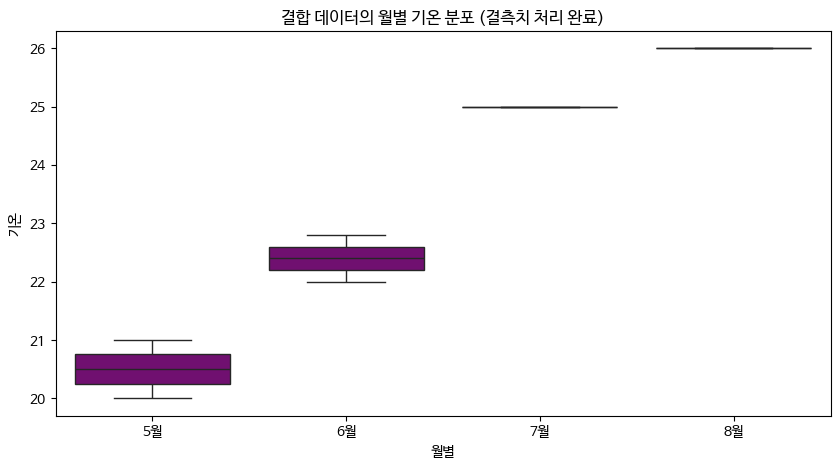

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # 데이터프레임의 시각화에 최적합
import matplotlib.font_manager as fm
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 및 폰트 설정
#-------------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#-------------------------------------------------------
# 2. 샘플 시계열 날씨 데이터 생성
#--------------------------------------------------------
df_2021 = pd.DataFrame({'기온': [20, 22, 25]}, index=['5월', '6월', '7월'])
df_2022 = pd.DataFrame({'기온': [21, np.nan, 26], '풍속': [3.2, 4.1, 3.8]}, index=['5월', '6월', '8월'])
print(df_2022)

#---------------------------------------------------------------------------------
# 3.모든 월 인덱스와 컬럼을 유지하며 물리적으로 결합 (axis = 0. join = 'outer')
#---------------------------------------------------------------------------------
combined = pd.concat([df_2021, df_2022], axis=0, keys=['2021년', '2022년'])
print("\n",combined)

# ---------------------------------------------------------
# 4. df.fillna()를 활용한 전략적 결측치 처리
# ---------------------------------------------------------
clean_df = combined.fillna({
    '기온': combined['기온'].mean(), # 기온은 평균값으로
    '풍속':0.0                       # 풍속 데이터가 없으면 무풍(0)으로 간주
})
print("\n", clean_df)

# ---------------------------------------------------------
# 5. 데이터프레임의 시각화는 seaborn 라이브러리 이용: 상자수염
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.boxplot(data = clean_df, x=clean_df.index.get_level_values(1), y='기온', color="purple") #multi-index
plt.xlabel("월별")
plt.title('결합 데이터의 월별 기온 분포 (결측치 처리 완료)')
plt.show()


## ✅ Pandas 기능
- pd.merge()

In [6]:
import pandas as pd

#-----------------------------------------------------------------------
# 1. 두 개의 테이블을 DataFrame으로 생성 : 공유하는 특정 키 열 존재
#------------------------------------------------------------------------
df_customers = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['김', '이', '박']}, index=['가','나','다'])  # 고객 정보
print("\n",df_customers)
df_purchase_items = pd.DataFrame({'ID': [2, 3, 4,5], 'Product': ['스마트폰', '노트북', '태블릿','컴퓨터']},
                                 index=['다', '라','마', '바']) # 구매 정보
print("\n",df_purchase_items)

#-----------------------------------------------------------------------------------------------------
# 2.공유 키(특정 열)값중에서 공통값들(교집합)에 대한 인덱스 행를 병합하기 : on='컬럼명',how = 'inner
#-----------------------------------------------------------------------------------------------------
combined = df_customers.merge(df_purchase_items, on="ID", how="inner")
print("\n",combined)


#----------------------------------------------------------------------------------------------
# 3.공유 키(특정 열)의 모든 값들(합집합)에 대한 인덱스 행을 병합하기 : on='컬럼명',how = 'outer'
#----------------------------------------------------------------------------------------------
combined = df_customers.merge(df_purchase_items, on="ID", how="outer")
print("\n",combined)


#---------------------------------------------------------------------------------------------------------------
# 4. 왼쪽 테이블의 공유 키에 대한 모든 인덱스가 나오고, 오른쪽 테이블의 정보를 덧붙이기. on='컬럼명', how='left'
#---------------------------------------------------------------------------------------------------------------
combined = df_customers.merge(df_purchase_items, on="ID", how="left")
print("\n",combined)


#----------------------------------------------------------------------------------------------------------------
# 5. 오른쪽 테이블의 공유 키에 대한 모든 인덱스가 나오고, 왼쪽 테이블의 정보를 덧붙이기. on='컬럼명', how='right'
#---------------------------------------------------------------------------------------------------------------
combined = df_customers.merge(df_purchase_items, on="ID", how="right")
print("\n",combined)



    ID Name
가   1    김
나   2    이
다   3    박

    ID Product
다   2    스마트폰
라   3     노트북
마   4     태블릿
바   5     컴퓨터

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   4  NaN     태블릿
4   5  NaN     컴퓨터

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북

    ID Name Product
0   2    이    스마트폰
1   3    박     노트북
2   4  NaN     태블릿
3   5  NaN     컴퓨터


## ✅ Pandas 기능
- pd.pivot_table()

In [7]:
import pandas as pd
import numpy as np

#----------------------------------------------------------------------------------------------------------
# 1. 데이터 생성
#----------------------------------------------------------------------------------------------------------
df_customers = pd.DataFrame({'ID': [1, 2, 3], 'Name': ['김', '이', '박']}, index=['가','나','다'])  # 고객 정보
df_purchase_items = pd.DataFrame({'ID': [2, 3, 3, 4, 5], 'Product': ['스마트폰', '노트북','스마트폰', '태블릿', '컴퓨터']},
                                 index=['다', '라','마', '바', '사']) # 구매 정보 (인덱스 길이를 데이터 길이에 맞춤)

print(df_customers)
print("\n",df_purchase_items)

#------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------
# 2. 데이터 병합 : 'ID'을 기준으로 모든 고객과 구매 정보을 유지하도록 병합 (merge)
#------------------------------------------------------------------------------------
combined = df_customers.merge(df_purchase_items, on="ID", how="outer")
print("\n",combined)

#-------------------------------------------------------------------------------
# 3. 데이터 가공 (피벗 전 처리)
#-------------------------------------------------------------------------------
# (1) Name 열에서 이름이 없는 경우에는 '비회원'으로 채우고, 업데이트하기
combined['Name'] = combined['Name'].fillna('비회원')
print("\n",combined)

# (2) 각 구매 수량을 1로 표시하는 '구매수량' 컬럼을 추가하기
combined['구매수량'] = np.random.randint(1,10,len(combined))
print("\n",combined)

#-------------------------------------------------------------------------------
# 4. 피벗 테이블 생성
#-------------------------------------------------------------------------------
# 행(index)은 고객 이름, 열(columns)은 상품명으로 설정하여 값(values)에 대해 구매 수량의 합을 집계하기.
combined_pivot = combined.pivot_table(index='Name', columns='Product', values='구매수량', aggfunc='sum', fill_value=0)
print("\n",combined_pivot)

   ID Name
가   1    김
나   2    이
다   3    박

    ID Product
다   2    스마트폰
라   3     노트북
마   3    스마트폰
바   4     태블릿
사   5     컴퓨터

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   3    박    스마트폰
4   4  NaN     태블릿
5   5  NaN     컴퓨터

    ID Name Product
0   1    김     NaN
1   2    이    스마트폰
2   3    박     노트북
3   3    박    스마트폰
4   4  비회원     태블릿
5   5  비회원     컴퓨터

    ID Name Product  구매수량
0   1    김     NaN     6
1   2    이    스마트폰     6
2   3    박     노트북     6
3   3    박    스마트폰     3
4   4  비회원     태블릿     1
5   5  비회원     컴퓨터     5

 Product  노트북  스마트폰  컴퓨터  태블릿
Name                        
박          6     3    0    0
비회원        0     0    5    1
이          0     6    0    0


## ✅ 시계열 날씨 데이터(프로그래밍과제)
- 웹상의 CSV 데이터를 읽어와 전처리(결측치 처리, 날짜 변환)를 수행하고,
- concat, merge, pivot_table 등 Pandas의 핵심 기능을 모두 포함한 통합 데이터 분석 파이프라인 코드를 작성.


✅ 환경 설정 및 한글 폰트 로드 완료
            평균기온  최대풍속  평균풍속
일시                          
2010-08-01  28.7   8.3   3.4
2010-08-02  25.2   8.7   3.8
2010-08-03  22.1   6.3   2.9
2010-08-04  25.3   6.6   4.2
2010-08-05  27.2   9.1   5.6
평균기온    28.7
최대풍속     8.3
평균풍속     3.4
Name: 2010-08-01, dtype: float64
Index(['2010-08-01', '2010-08-02', '2010-08-03', '2010-08-04', '2010-08-05',
       '2010-08-06', '2010-08-07', '2010-08-08', '2010-08-09', '2010-08-10',
       ...
       '2020-07-22', '2020-07-23', '2020-07-24', '2020-07-25', '2020-07-26',
       '2020-07-27', '2020-07-28', '2020-07-29', '2020-07-30', '2020-07-31'],
      dtype='object', name='일시', length=3653)


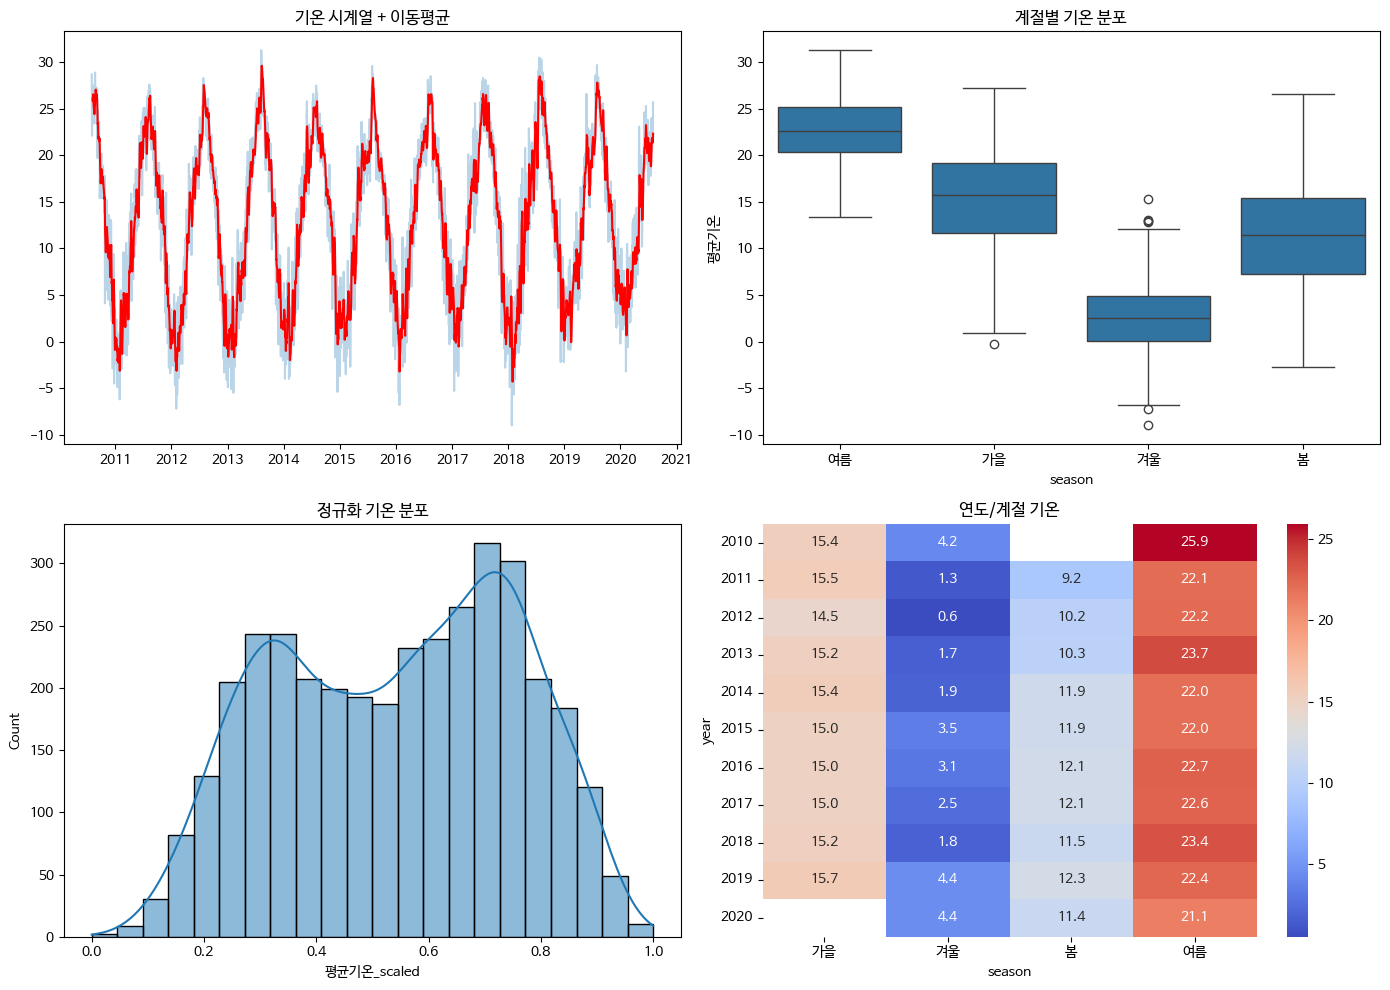

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 설정
# ---------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

#-----------------------------------------------------------------
# 데이터 로드
#-----------------------------------------------------------------
path = 'https://github.com/dongupak/DataML/raw/main/csv/'
weather = pd.read_csv(path + 'weather.csv', index_col= "일시", encoding='CP949') # 반환 객체 -DateFrame!!!!
print(weather.head())
print(weather.loc['2010-08-01'])
print(weather.index)

# ---------------------------------------------------------
# 2. 전처리
# ---------------------------------------------------------
def preprocess_data(df):
    df.index = pd.to_datetime(df.index)
    df = df.fillna(method='ffill')
    return df


# ---------------------------------------------------------
# 3. Min-Max 정규화
# ---------------------------------------------------------
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())


# ---------------------------------------------------------
# 4. 특징 생성
# ---------------------------------------------------------
def create_features(df):
    df['7day_avg'] = df['평균기온'].rolling(7).mean()
    df['month'] = df.index.month
    df['year'] = df.index.year

    def get_season(month):
        if month in [3,4,5]: return '봄'
        elif month in [6,7,8]: return '여름'
        elif month in [9,10,11]: return '가을'
        else: return '겨울'

    df['season'] = df['month'].apply(get_season)
    df['평균기온_scaled'] = min_max_scale(df['평균기온'])

    return df


# ---------------------------------------------------------
# 5. concat + merge
# ---------------------------------------------------------
def combine_data(df):
    df_copy = df.copy()
    df_copy['평균기온'] += 2

    concat_df = pd.concat([df, df_copy])

    extra = pd.DataFrame({
        'date': df.index,
        'rain_flag': np.where(df['평균풍속'] > 0, 1, 0)
    }).set_index('date')

    merge_df = pd.merge(df, extra, left_index=True, right_index=True)

    return concat_df, merge_df


# ---------------------------------------------------------
# 6. 분석 (groupby + pivot)
# ---------------------------------------------------------
def analyze_data(df):
    seasonal_stats = df.groupby('season')['평균기온'].describe()

    pivot = df.pivot_table(
        values='평균기온',
        index='year',
        columns='season',
        aggfunc='mean'
    )

    return seasonal_stats, pivot


# ---------------------------------------------------------
# 7. 시각화
# ---------------------------------------------------------
def visualize(df, pivot):
    plt.figure(figsize=(14,10))

    # 시계열 + 이동평균
    plt.subplot(2,2,1)
    plt.plot(df.index, df['평균기온'], alpha=0.3)
    plt.plot(df.index, df['7day_avg'], color='red')
    plt.title('기온 시계열 + 이동평균')

    # 박스플롯
    plt.subplot(2,2,2)
    sns.boxplot(x='season', y='평균기온', data=df)
    plt.title('계절별 기온 분포')

    # 히스토그램
    plt.subplot(2,2,3)
    sns.histplot(df['평균기온_scaled'], kde=True)
    plt.title('정규화 기온 분포')

    # 히트맵
    plt.subplot(2,2,4)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm')
    plt.title('연도/계절 기온')

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 8. 엑셀 저장
# ---------------------------------------------------------
def save_to_excel(df, seasonal_stats, pivot):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='preprocessed')
        seasonal_stats.to_excel(writer, sheet_name='season_stats')
        pivot.to_excel(writer, sheet_name='pivot_table')


# ---------------------------------------------------------
# 9. 실행
# ---------------------------------------------------------
weather = preprocess_data(weather)
weather = create_features(weather)

concat_df, merge_df = combine_data(weather)
seasonal_stats, pivot = analyze_data(weather)

visualize(weather, pivot)
save_to_excel(weather, seasonal_stats, pivot)

In [9]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful